# **Neural Networks and Deep Learning**

## **CHAPTER 9 Up and Running with TensorFlow**

In [ ]:
import tensorflow as tf

In [ ]:
print(tf.__version__)
print(tf.config.list_physical_devices("GPU"))


2.20.0
[]


In [ ]:
x = tf.Variable(3, name="x")
y = tf.Variable(4, name="y")
f = x*x*y + y + 2

In [ ]:
print(f)

tf.Tensor(42, shape=(), dtype=int32)


In [ ]:
result = f.numpy()

print(result)

42


In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
iris = load_iris()
X = iris.data[:, (2, 3)] # petal length, petal width
y = (iris.target == 0).astype(np.int32) # Iris setosa?
per_clf = Perceptron()
per_clf.fit(X, y)
y_pred = per_clf.predict([[2, 0.5]])

In [ ]:
y_pred

array([0], dtype=int32)

In [ ]:
from tensorflow import keras
print(tf.__version__)
print(keras.__version__)


2.20.0
3.13.2


# ***Building an Image Classifier Using the Sequential API***

In [ ]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
print(X_train_full.shape)
print(X_train_full.dtype)

(60000, 28, 28)
uint8


In [ ]:
from sklearn.model_selection import train_test_split

fashion_mnist = keras.datasets.fashion_mnist

(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    stratify=y_train_full,
    random_state=42
)

# Normalize pixel values to [0, 1]
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [ ]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

In [ ]:
class_names[y_train[4]]

'T-shirt/top'

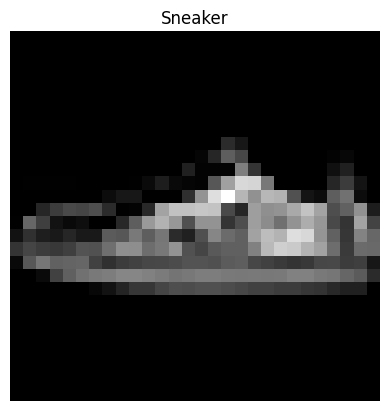

In [ ]:
import matplotlib.pyplot as plt

k = 33

plt.imshow(X_train[k], cmap="gray")
plt.title(class_names[y_train[k]])
plt.axis("off")
plt.show()

In [ ]:
# model = keras.Sequential([
#     keras.layers.Input(shape=[28, 28]),
#     keras.layers.Flatten(),
#     keras.layers.Dense(300, activation="relu"),
#     keras.layers.Dense(100, activation="relu"),
#     keras.layers.Dense(10, activation="softmax")
# ])

In [ ]:
from keras import regularizers
model = keras.Sequential()
model.add(keras.layers.Input(shape=[28,28]))
model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(392, activation='relu', kernel_regularizer=regularizers.l2(0.001)))

model.add(keras.layers.Dense(196, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
model.add(keras.layers.Dropout(0.2))

model.add(keras.layers.Dense(98, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
model.add(keras.layers.Dropout(0.3))

model.add(keras.layers.Dense(10, activation='softmax'))

In [ ]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 392)            │       307,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 196)            │        77,028 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 196)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 98)             │        19,306 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 98)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 405,044 (1.55 MB)

 Trainable params: 405,044 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.layers

[<Flatten name=flatten_4, built=True>,
 <Dense name=dense_13, built=True>,
 <Dense name=dense_14, built=True>,
 <Dropout name=dropout_5, built=True>,
 <Dense name=dense_15, built=True>,
 <Dropout name=dropout_6, built=True>,
 <Dense name=dense_16, built=True>]

In [ ]:
hidden1 = model.layers[1]

In [ ]:
hidden1.name


'dense_13'

In [ ]:
# model.get_layer('dense_3') is hidden1

In [ ]:
weights, biases = hidden1.get_weights()

In [ ]:
weights

array([[-0.0447723 ,  0.05053204,  0.00794637, ...,  0.02271562,
        -0.02829378,  0.04653311],
       [ 0.05485236,  0.01597134,  0.0228427 , ...,  0.05584391,
         0.04839661,  0.05122633],
       [ 0.00213055,  0.06375993,  0.02492978, ..., -0.05530947,
         0.04068059, -0.06700855],
       ...,
       [-0.01774286, -0.02270334,  0.01671977, ..., -0.04050076,
         0.06714451, -0.02925177],
       [-0.04974985, -0.06885548,  0.0626817 , ..., -0.00938167,
        -0.0343139 , -0.03865392],
       [ 0.07124709,  0.02644379,  0.04522905, ..., -0.00261968,
         0.01384253,  0.01142369]], dtype=float32)

In [ ]:
# biases

In [ ]:
weights.shape

(784, 392)

In [ ]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [ ]:
import tensorflow as tf

print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0,
    patience=15,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=True,
    start_from_epoch=0
)

history = model.fit(
    X_train,
    y_train,
    epochs=200,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)


Epoch 1/200
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7907 - loss: 0.9560 - val_accuracy: 0.8445 - val_loss: 0.6388
Epoch 2/200
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8383 - loss: 0.6302 - val_accuracy: 0.8422 - val_loss: 0.5835
Epoch 3/200
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8462 - loss: 0.5627 - val_accuracy: 0.8560 - val_loss: 0.5169
Epoch 4/200
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8549 - loss: 0.5278 - val_accuracy: 0.8572 - val_loss: 0.5026
Epoch 5/200
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8573 - loss: 0.5113 - val_accuracy: 0.8626 - val_loss: 0.4916
Epoch 6/200
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8602 - loss: 0.4996 - val_accuracy: 0.8697 - val_loss: 0.4702
Epoch 7/200
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8629 - loss: 0.4884 - val_accuracy: 0.8672 - val_loss: 0.4690
Epoch 8/200
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8652 - loss: 0

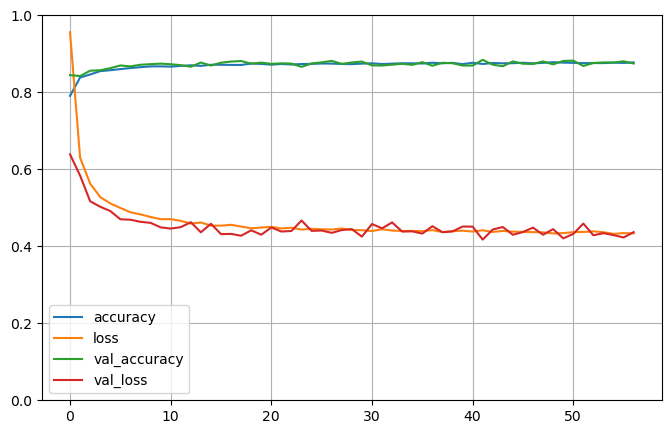

In [ ]:
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [ ]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8682 - loss: 0.4628


[0.4628432095050812, 0.8682000041007996]

In [ ]:
X_new = X_test[:3]


In [ ]:
y_proba = model.predict(X_new)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 583ms/step


In [ ]:
y_proba.round(2)

array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.28, 0.  , 0.71],
       [0.  , 0.  , 0.98, 0.  , 0.01, 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]],
      dtype=float32)

In [ ]:
y_proba = model.predict(X_new)

y_pred = y_proba.argmax(axis=1)

print(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[9 2 1]


In [ ]:
np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

### **Building a Regression MLP Using the Sequential API**

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
housing = fetch_california_housing()
X = housing.data
y = housing.target
X_train_full, X_test, y_train_full, y_test = train_test_split( X, y, random_state=42, test_size=0.2)

X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, random_state=42, test_size=0.2)


In [ ]:
X_train

array([[   4.7069    ,   27.        ,    6.52325581, ...,    3.38372093,
          38.        , -120.97      ],
       [   3.875     ,   15.        ,    5.05840568, ...,    2.65114444,
          34.1       , -117.87      ],
       [   2.8828    ,   26.        ,    5.29061785, ...,    2.91304348,
          33.76      , -117.85      ],
       ...,
       [   3.9844    ,   18.        ,    5.54983389, ...,    3.24252492,
          32.74      , -116.99      ],
       [   4.5112    ,   16.        ,    4.41428571, ...,    2.08571429,
          33.84      , -117.87      ],
       [   4.2       ,   35.        ,    4.37209302, ...,    2.97674419,
          33.91      , -118.32      ]])

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

In [ ]:
model = keras.models.Sequential([
    keras.layers.Input(shape=X_train.shape[1:]),
    keras.layers.Dense(30, activation="relu", input_shape=X_train.shape[1:]),
    keras.layers.Dense(1)
])
model.compile(loss="mean_squared_error", optimizer="adam")

In [ ]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 301 (1.18 KB)

 Trainable params: 301 (1.18 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))

Epoch 1/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1.4327 - val_loss: 0.6586
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5457 - val_loss: 0.5276
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4407 - val_loss: 0.4368
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4051 - val_loss: 0.4259
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3890 - val_loss: 0.4097
Epoch 6/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3777 - val_loss: 0.4035
Epoch 7/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3703 - val_loss: 0.4085
Epoch 8/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3637 - val_loss: 0.3824
Epoch 9/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3562 - val_loss: 0.3897
Epoch 10/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3524 - val_loss: 0.4317
Epoch 11/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3546 - val_loss: 0.4170
Epoch 12/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

In [ ]:
mse_test = model.evaluate(X_test, y_test)
mse_test

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3476


0.34761762619018555

In [ ]:
X_new = X_test[:3] # pretend these are new instances
y_pred = model.predict(X_new)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


array([[0.6056478],
       [1.5651215],
       [4.059428 ]], dtype=float32)

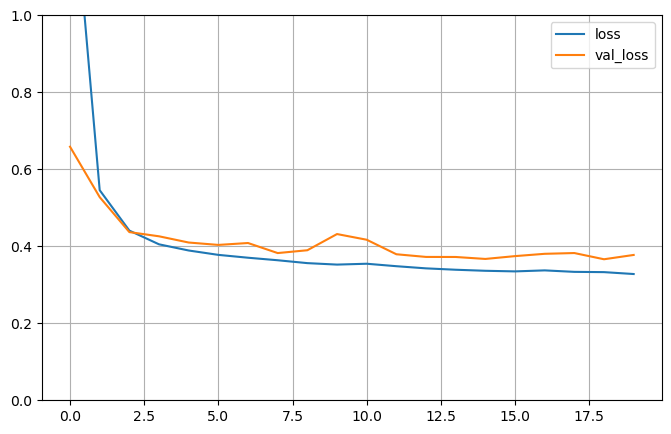

In [ ]:
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

### **GPT Model**

In [ ]:
model = keras.models.Sequential([
    keras.layers.Input(shape=X_train.shape[1:]),

    # Increase from 64 to 128 neurons
    keras.layers.Dense(128, activation="relu", kernel_initializer="he_normal"),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),  # Marginally higher dropout for a wider layer

    # Increase from 30 to 64 neurons
    keras.layers.Dense(64, activation="relu", kernel_initializer="he_normal"),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.2),

    keras.layers.Dense(1)
])

# Try a slightly higher initial learning rate if the data is heavily scaled,
# or change the epsilon value to stabilize Adam's denominator
optimizer = keras.optimizers.Adam(learning_rate=0.005, epsilon=1e-07)

model.compile(loss="mean_squared_error", optimizer=optimizer)

callbacks = [
    # Halves the learning rate if validation loss doesn't improve for 3 epochs
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1,
        min_lr=1e-5
    ),
    # Stops training when val_loss stops improving and restores the best weights
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    )
]

history = model.fit(
    X_train, y_train,
    epochs=50,  # Increased because Early Stopping will catch it safely
    batch_size=32,  # Tuning batch size can also stabilize the loss curve
    validation_data=(X_valid, y_valid),
    callbacks=callbacks
)

Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.9979 - val_loss: 0.5481 - learning_rate: 0.0050
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5007 - val_loss: 0.4908 - learning_rate: 0.0050
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4642 - val_loss: 0.4111 - learning_rate: 0.0050
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4359 - val_loss: 0.4397 - learning_rate: 0.0050
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4255 - val_loss: 0.4079 - learning_rate: 0.0050
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4254 - val_loss: 0.4173 - learning_rate: 0.0050
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4229 - val_loss: 0.3696 - learning_rate: 0.0050
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4112 - val_loss: 0.4156 - learning_rate: 0.0050
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3972 - val_loss: 0.4900 - learning_rate: 0.0050
Epoch 10/5

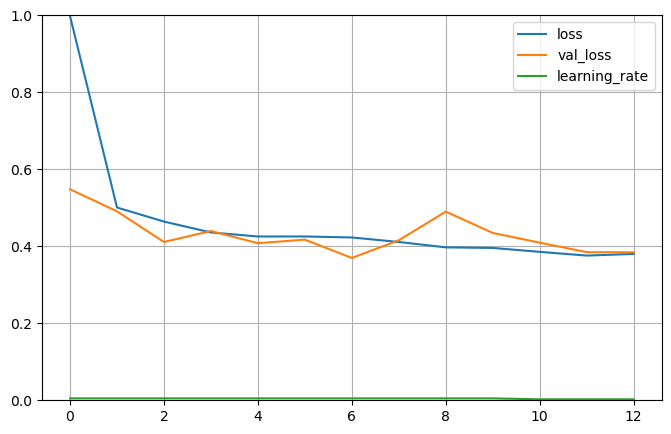

In [ ]:
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

### **Building Complex Models Using the Functional API**

In [ ]:
x = np.arange(20).reshape(2, 2, 5)
print('\n\n')
y = np.arange(20, 30).reshape(2, 1, 5)
z= keras.layers.Concatenate(axis=1)([x, y])


In [ ]:
print(x)
print('\n\n')

print(y)
print('\n\n')

print(z)

[[[ 0  1  2  3  4]
  [ 5  6  7  8  9]]

 [[10 11 12 13 14]
  [15 16 17 18 19]]]



[[[20 21 22 23 24]]

 [[25 26 27 28 29]]]



tf.Tensor(
[[[ 0  1  2  3  4]
  [ 5  6  7  8  9]
  [20 21 22 23 24]]

 [[10 11 12 13 14]
  [15 16 17 18 19]
  [25 26 27 28 29]]], shape=(2, 3, 5), dtype=int64)


```
You can visualize it hierarchically from the outside in:

First dimension (2): The number of outer groups, matrices, or batches. It means you have 2 separate blocks.

Second dimension (3): The number of rows in each block.

Third dimension (5): The number of columns (or elements) in each row.
```

In [ ]:
input_ = keras.layers.Input(shape=X_train.shape[1:])
hidden1 = keras.layers.Dense(30, activation="relu")(input_)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.Concatenate()([input_, hidden2])
output = keras.layers.Dense(1)(concat)
model = keras.Model(inputs=[input_], outputs=[output])

In [ ]:
model.summary()

Model: "functional_38"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_40 (Dense)    │ (None, 30)        │        270 │ input_layer_14[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_41 (Dense)    │ (None, 30)        │        930 │ dense_40[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 38)        │          0 │ input_layer_14[0… │
│ (Concatenate)       │                   │            │ dense_41[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_42 (Dense)    │ (None, 1)         │         39 │ concatenate_3[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,239 (4.84 KB)

 Trainable params: 1,239 (4.84 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
input_A = keras.layers.Input(shape=[5], name="wide_input")
input_B = keras.layers.Input(shape=[6], name="deep_input")
hidden1 = keras.layers.Dense(30, activation="relu")(input_B)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.concatenate([input_A, hidden2])
output = keras.layers.Dense(1, name="output")(concat)
model = keras.Model(inputs=[input_A, input_B], outputs=[output])

In [ ]:
model.summary()

Model: "functional_39"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ deep_input          │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_43 (Dense)    │ (None, 30)        │        210 │ deep_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wide_input          │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_44 (Dense)    │ (None, 30)        │        930 │ dense_43[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 35)        │          0 │ wide_input[0][0], │
│ (Concatenate)       │                   │            │ dense_44[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         36 │ concatenate_4[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,176 (4.59 KB)

 Trainable params: 1,176 (4.59 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss="mse", optimizer=keras.optimizers.SGD(learning_rate=1e-3))

X_train_A, X_train_B = X_train[:, :5], X_train[:, 2:]

X_valid_A, X_valid_B = X_valid[:, :5], X_valid[:, 2:]

X_test_A, X_test_B = X_test[:, :5], X_test[:, 2:]

X_new_A, X_new_B = X_test_A[:3], X_test_B[:3]

history = model.fit((X_train_A, X_train_B), y_train, epochs=20,
                    validation_data=((X_valid_A, X_valid_B), y_valid))

mse_test = model.evaluate((X_test_A, X_test_B), y_test)

y_pred = model.predict((X_new_A, X_new_B))

Epoch 1/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4074 - val_loss: 0.4308
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4057 - val_loss: 0.4441
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4037 - val_loss: 0.4273
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4035 - val_loss: 0.4326
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4015 - val_loss: 0.4350
Epoch 6/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4003 - val_loss: 0.4402
Epoch 7/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3987 - val_loss: 0.4344
Epoch 8/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3965 - val_loss: 0.4215
Epoch 9/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3961 - val_loss: 0.4259
Epoch 10/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3956 - val_loss: 0.4217
Epoch 11/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3931 - val_loss: 0.4224
Epoch 12/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

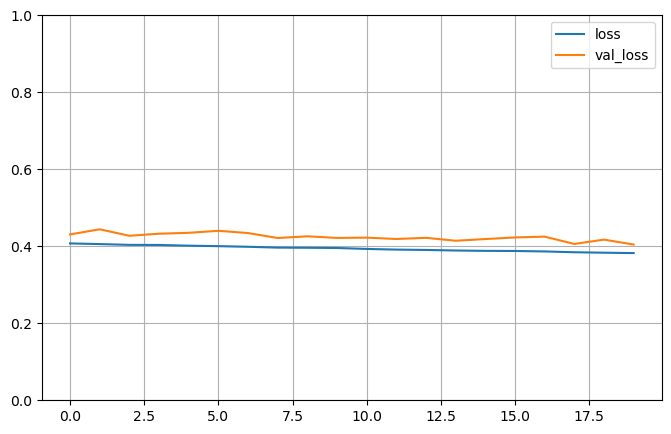

In [ ]:
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

In [ ]:
input_A = keras.layers.Input(shape=[5], name='wide_features')
input_B = keras.layers.Input(shape=[6], name='deep_features')
h1 = keras.layers.Dense(30, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(input_B)
h2 = keras.layers.Dense(30, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001))(h1)
concat = keras.layers.concatenate([input_A, h2])
output1 = keras.layers.Dense(1, name='output1')(concat)
output2 = keras.layers.Dense(1,name='output2')(h2)
model = keras.Model(inputs=[input_A, input_B], outputs=[output1, output2])

In [ ]:
X_train_A.shape

(13209, 5)

In [ ]:
X_train_A

array([[ 0.44340968, -0.12449485,  0.5204714 ,  0.05758629, -0.48710064],
       [ 0.00321001, -1.07770852, -0.17083875, -0.04872181,  1.69902706],
       [-0.52181236, -0.20392932, -0.06125032,  0.28089603, -0.13535041],
       ...,
       [ 0.061099  , -0.8394051 ,  0.06108211, -0.20832847,  0.46174561],
       [ 0.33985508, -0.99827405, -0.47481979, -0.2175701 , -0.61285135],
       [ 0.17518368,  0.51098093, -0.49473189, -0.46726841, -0.69199516]])

In [ ]:
model.summary()

Model: "functional_40"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ deep_features       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_45 (Dense)    │ (None, 30)        │        210 │ deep_features[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wide_features       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_46 (Dense)    │ (None, 30)        │        930 │ dense_45[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 35)        │          0 │ wide_features[0]… │
│ (Concatenate)       │                   │            │ dense_46[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output1 (Dense)     │ (None, 1)         │         36 │ concatenate_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output2 (Dense)     │ (None, 1)         │         31 │ dense_46[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,207 (4.71 KB)

 Trainable params: 1,207 (4.71 KB)

 Non-trainable params: 0 (0.00 B)

***Each output will need its own loss function.***

In [ ]:
model.compile( loss=["mse", "mse"], loss_weights=[0.9, 0.1], optimizer="adam")

In [ ]:
history = model.fit(
    [X_train_A, X_train_B],
    [y_train, y_train],
    epochs=20,
    validation_data=[[X_valid_A, X_valid_B], [y_valid, y_valid]]
)


Epoch 1/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - loss: 1.6305 - output1_loss: 1.5214 - output2_loss: 2.1954 - val_loss: 0.8755 - val_output1_loss: 0.7327 - val_output2_loss: 1.7209
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.6378 - output1_loss: 0.5837 - output2_loss: 0.6852 - val_loss: 0.6496 - val_output1_loss: 0.5778 - val_output2_loss: 0.8638
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.5461 - output1_loss: 0.4949 - output2_loss: 0.5755 - val_loss: 0.5857 - val_output1_loss: 0.5280 - val_output2_loss: 0.6790
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.4926 - output1_loss: 0.4402 - output2_loss: 0.5416 - val_loss: 0.5191 - val_output1_loss: 0.4631 - val_output2_loss: 0.6099
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.4576 - output1_loss: 0.4053 - output2_loss: 0.5189 - val_loss: 0.4857 - val_output1_loss: 0.4316 - val_output2_loss: 0.5708
Epoch 6/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.4

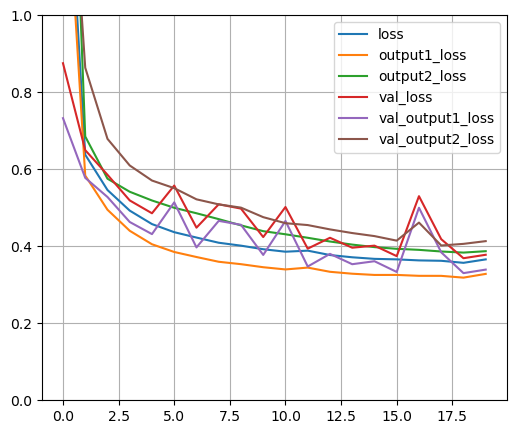

In [ ]:
pd.DataFrame(history.history).plot(figsize=(6,5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

In [ ]:
total_loss, main_loss, aux_loss = model.evaluate(
[X_test_A, X_test_B], [y_test, y_test])

129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.3774 - output1_loss: 0.3413 - output2_loss: 0.3887


In [ ]:
print(total_loss)
print(main_loss)
print(aux_loss)

0.3774182200431824
0.3413194715976715
0.3886720836162567


In [ ]:
y_pred_main, y_pred_aux = model.predict([X_new_A, X_new_B])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [ ]:
y_pred_main.round(0)

array([[0.],
       [2.],
       [4.]], dtype=float32)

In [ ]:
y_pred_aux.round()

array([[1.],
       [2.],
       [3.]], dtype=float32)

# **Saving and Restoring a Model**

***This will work when using the Sequential API or the Functional API, but unfortunately not when using model subclassing.***

In [ ]:
model.save(r'/home/noneo/Codes/ML/MachineLearning/Hand_On_ML/Models/complexmodelofcalifornia.h5')

In [ ]:
model.save(r'/home/noneo/Codes/ML/MachineLearning/Hand_On_ML/Models/complexmodelofcalifornia.keras')


### **Using the Subclassing API to Build Dynamic Models**

![image.png](attachment:image.png)

In [ ]:
class WideAndDeepModel(keras.Model):
    def __init__(self, units=30, activation='relu', *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.h1 = keras.layers.Dense(units=units, activation=activation, kernel_regularizer=keras.regularizers.l2(0.001))
        self.h2 = keras.layers.Dense(units=units, activation=activation, kernel_regularizer=keras.regularizers.l2(0.001))
        self.main_output = keras.layers.Dense(1)
        self.aux_output = keras.layers.Dense(1)

    def call(self, inputs):
        input_A, input_B = inputs
        h1 = self.h1(input_B)
        h2 = self.h2(h1)
        concat = keras.layers.concatenate([input_A, h2])
        main_output = self.main_output(concat)
        aux_output = self.aux_output(h2)
        return main_output, aux_output

model1 = WideAndDeepModel()

model1.compile(loss=["mse", "mse"], loss_weights=[0.9, 0.1], optimizer="adam")

history = model1.fit(
    [X_train_A, X_train_B],
    [y_train, y_train],
    epochs=5,
    validation_data=[[X_valid_A, X_valid_B], [y_valid, y_valid]]
)


Epoch 1/5


413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 1.3718 - mse_loss: 1.9206 - val_loss: 0.7877 - val_mse_loss: 1.6571
Epoch 2/5
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5280 - mse_loss: 0.7644 - val_loss: 0.5272 - val_mse_loss: 0.7030
Epoch 3/5
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4863 - mse_loss: 0.6020 - val_loss: 0.5275 - val_mse_loss: 0.6326
Epoch 4/5
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4727 - mse_loss: 0.5622 - val_loss: 0.6378 - val_mse_loss: 0.6248
Epoch 5/5
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4643 - mse_loss: 0.5445 - val_loss: 0.6189 - val_mse_loss: 0.6347


In [ ]:
model1.summary()

Model: "wide_and_deep_model_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_55 (Dense)                │ (None, 30)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 1)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,623 (14.16 KB)

 Trainable params: 1,207 (4.71 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,416 (9.44 KB)

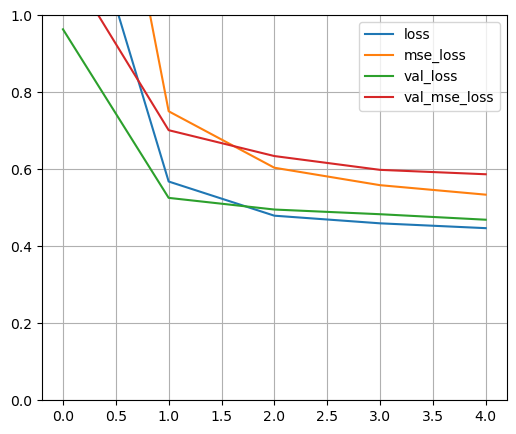

In [ ]:
pd.DataFrame(history.history).plot(figsize=(6,5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

In [ ]:
total_loss, main_loss, aux_loss = model.evaluate(
    [X_test_A, X_test_B], [y_test, y_test]
)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4544 - mse_loss: 0.5169


# **Loading Model**

In [ ]:
model = keras.models.load_model(r'/home/noneo/Codes/ML/MachineLearning/Hand_On_ML/Models/complexmodelofcalifornia.keras')

/home/noneo/miniconda3/envs/aienv/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
model.summary()

Model: "functional_40"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ deep_features       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_45 (Dense)    │ (None, 30)        │        210 │ deep_features[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wide_features       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_46 (Dense)    │ (None, 30)        │        930 │ dense_45[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 35)        │          0 │ wide_features[0]… │
│ (Concatenate)       │                   │            │ dense_46[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output1 (Dense)     │ (None, 1)         │         36 │ concatenate_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output2 (Dense)     │ (None, 1)         │         31 │ dense_46[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,416 (9.44 KB)

 Trainable params: 1,207 (4.71 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,209 (4.73 KB)

# **Using CallBacks**

```
what if training lasts several hours? This is quite common, especially when train‐
ing on large datasets. In this case, you should not only save your model at the end of
training, but also save checkpoints at regular intervals during training, to avoid losing
everything if your computer crashes
```

In [ ]:
checkpoint_cb = keras.callbacks.ModelCheckpoint("/home/noneo/Codes/ML/MachineLearning/Hand_On_ML/Models/complexmodelofcalifornia..keras")

In [ ]:
history = model1.fit(
    [X_train_A, X_train_B],
    [y_train, y_train],
    epochs=5,
    callbacks=[checkpoint_cb],
    validation_data=[[X_valid_A, X_valid_B], [y_valid, y_valid]]
)

Epoch 1/5


413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4069 - mse_loss: 0.4358 - val_loss: 0.4152 - val_mse_loss: 0.4523
Epoch 2/5
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3913 - mse_loss: 0.4145 - val_loss: 0.4124 - val_mse_loss: 0.4422
Epoch 3/5
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3914 - mse_loss: 0.4092 - val_loss: 0.4208 - val_mse_loss: 0.4401
Epoch 4/5
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3873 - mse_loss: 0.4118 - val_loss: 0.6857 - val_mse_loss: 0.9636
Epoch 5/5
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4119 - mse_loss: 0.4301 - val_loss: 0.4254 - val_mse_loss: 0.4355


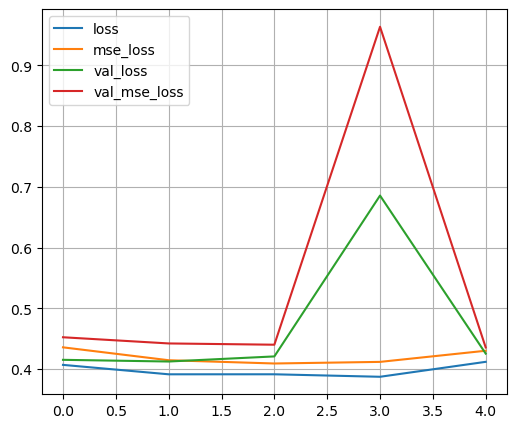

In [ ]:
pd.DataFrame(history.history).plot(figsize=(6,5))
plt.grid(True)
plt.show()

In [ ]:
checkpoint_cb = keras.callbacks.ModelCheckpoint("/home/noneo/Codes/ML/MachineLearning/Hand_On_ML/Models/complexmodelofcalifornia..keras", save_best_only=True)


In [ ]:
history = model1.fit(
    [X_train_A, X_train_B],
    [y_train, y_train],
    epochs=5,
    callbacks=[checkpoint_cb],
    validation_data=[[X_valid_A, X_valid_B], [y_valid, y_valid]]
)

Epoch 1/5
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3792 - mse_loss: 0.3991 - val_loss: 0.4139 - val_mse_loss: 0.4268
Epoch 2/5
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3761 - mse_loss: 0.3934 - val_loss: 0.4013 - val_mse_loss: 0.4406
Epoch 3/5
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3783 - mse_loss: 0.3991 - val_loss: 0.4543 - val_mse_loss: 0.4809
Epoch 4/5
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3763 - mse_loss: 0.3955 - val_loss: 0.3876 - val_mse_loss: 0.4121
Epoch 5/5
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3720 - mse_loss: 0.3911 - val_loss: 0.4367 - val_mse_loss: 0.4642


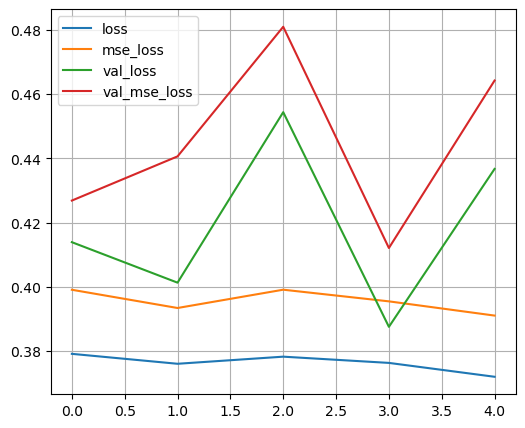

In [ ]:
pd.DataFrame(history.history).plot(figsize=(6,5))
plt.grid(True)
plt.show()

# **Using Early Stop:**

```
use the EarlyStopping call‐back. It will interrupt training when it measures no progress on the validation set for a number of epochs (defined by the patience argument), and it will optionally roll back to the best model. You can combine both callbacks to save checkpoints of your model (in case your computer crashes) and interrupt training early when there is no more progress (to avoid wasting time and resources)
```

In [ ]:
early_stop = keras.callbacks.EarlyStopping(patience=3,restore_best_weights=True)

history = model1.fit(
    [X_train_A, X_train_B],
    [y_train, y_train],
    epochs=5,
    callbacks=[checkpoint_cb, early_stop],
    validation_data=[[X_valid_A, X_valid_B], [y_valid, y_valid]]
)

Epoch 1/5
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3603 - mse_loss: 0.3805 - val_loss: 0.4055 - val_mse_loss: 0.4384
Epoch 2/5
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3616 - mse_loss: 0.3834 - val_loss: 0.3897 - val_mse_loss: 0.4147
Epoch 3/5
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3602 - mse_loss: 0.3804 - val_loss: 0.3873 - val_mse_loss: 0.4147
Epoch 4/5
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3685 - mse_loss: 0.3954 - val_loss: 0.4621 - val_mse_loss: 0.4885
Epoch 5/5
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3619 - mse_loss: 0.3823 - val_loss: 0.3753 - val_mse_loss: 0.4010


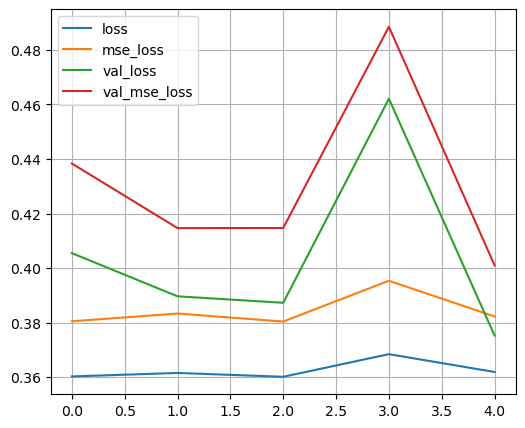

In [ ]:
pd.DataFrame(history.history).plot(figsize=(6,5))
plt.grid(True)
plt.show()

# **Using TensorBoard for Visualization**

In [ ]:
import os
import time
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from scipy.stats import reciprocal
from tensorflow import keras

In [ ]:
root_logdir = os.path.join(os.curdir, "my_logs")

In [ ]:
def get_run_logdir():
    import time
    run_id = time.strftime("run_%Y_%m_%d-%H_%M_%S")
    return os.path.join(root_logdir, run_id)

run_logdir = get_run_logdir()

In [ ]:
tensorboard_cb = keras.callbacks.TensorBoard(run_logdir)

history = model.fit(
    [X_train_A, X_train_B],
    [y_train, y_train],
    epochs=10,
    callbacks=[checkpoint_cb, early_stop, tensorboard_cb],
    validation_data=[[X_valid_A, X_valid_B], [y_valid, y_valid]]
)

Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3403 - output1_loss: 0.3086 - output2_loss: 0.3637 - val_loss: 0.3876 - val_output1_loss: 0.3562 - val_output2_loss: 0.4118
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3371 - output1_loss: 0.3057 - output2_loss: 0.3597 - val_loss: 0.3649 - val_output1_loss: 0.3305 - val_output2_loss: 0.4196
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3367 - output1_loss: 0.3053 - output2_loss: 0.3595 - val_loss: 0.3502 - val_output1_loss: 0.3186 - val_output2_loss: 0.3849


In [ ]:
test_logdir = get_run_logdir()
writer = tf.summary.create_file_writer(test_logdir)

with writer.as_default():
    for step in range(1, 1000 + 1):
        tf.summary.scalar("my_scalar", np.sin(step / 10), step=step)
        data = (np.random.randn(100) + 2) * step / 100 # some random data

        tf.summary.histogram("my_hist", data, buckets=50, step=step)
        images = np.random.rand(2, 32, 32, 3) # random 32×32 RGB images

        tf.summary.image("my_images", images * step / 1000, step=step)
        texts = ["The step is " + str(step), "Its square is " + str(step**2)]

        tf.summary.text("my_text", texts, step=step)
        sine_wave = tf.math.sin(tf.range(12000) / 48000 * 2 * np.pi * step)

        audio = tf.reshape(tf.cast(sine_wave, tf.float32), [1, -1, 1])
        tf.summary.audio("my_audio", audio, sample_rate=48000, step=step)

# **Fine-Tuning Neural Network Hyperparameters**

In [ ]:
X.shape

(20640, 8)

In [ ]:
housing = fetch_california_housing()
X = housing.data
y = housing.target

X_train_full, X_test, y_train_full, y_test = train_test_split( X, y, random_state=42, test_size=0.2)

X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full,
                                                      random_state=42, test_size=0.2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

X_train_A = X_train_scaled[:, :8]
X_valid_A = X_valid_scaled[:, :8]
X_test_A = X_test_scaled[:, :8]

root_logdir = os.path.join(os.curdir, "my_logs/finetuneDeepLearningModel")

def run_logdirtime():
    import time
    run_log = time.strftime('Run_%Y_%m_%d_%H_%M_%S')
    return os.path.join(root_logdir, run_log)

run_log_cb = run_logdirtime()

tensorboard_cb = keras.callbacks.TensorBoard(run_log_cb)

def build_model(n_hidden=2, n_neurons=30, activation='relu', learning_rate=0.003, input_shape=(8,), **kwargs):
    model = keras.models.Sequential()
    model.add(keras.layers.Input(shape=input_shape))

    for layer in range(n_hidden):
        model.add(keras.layers.Dense(units=n_neurons, activation=activation,
                                     kernel_regularizer=keras.regularizers.l2(0.001)))

    model.add(keras.layers.Dense(1))
    model.compile(loss='mse', optimizer=keras.optimizers.Adam(learning_rate=learning_rate))
    return model


```
Automation via Hyperparameter Tuning (The Main Reason)
If you want to find the best configuration for your model, you normally have to manually rewrite and test combinations of layers, neurons, and learning rates.

Because your model now looks like a Scikit-Learn estimator, you can pass this keras_reg object straight into Scikit-Learn’s native search tools like RandomizedSearchCV or GridSearchCV. Scikit-Learn will automatically run dozens of experiments, tweaking n_hidden, n_neurons, and learning_rate for you, and will output the best possible architecture.
```

In [ ]:
keras_reg = keras.wrappers.SKLearnRegressor(build_model)

In [ ]:
keras_reg.fit(
    X_train_A, y_train, epochs=100,
    validation_data=(X_valid_A, y_valid),
    callbacks=[keras.callbacks.EarlyStopping(patience=10), tensorboard_cb]
)

Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.7552 - val_loss: 0.4446
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4134 - val_loss: 0.4391
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4077 - val_loss: 0.6689
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3978 - val_loss: 0.4168
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3804 - val_loss: 0.9313
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4067 - val_loss: 0.4080
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3617 - val_loss: 0.3858
Epoch 8/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3567 - val_loss: 0.3782
Epoch 9/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3551 - val_loss: 0.3943
Epoch 10/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3492 - val_loss: 0.3697
Epoch 11/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3469 - val_loss: 0.3987
Epoch 12/100
413/413 ━━━━━━━━━━━━━━━━━━━━

SKLearnRegressor(model=<function build_model at 0x7932a7e22de0>)

In [ ]:
mse_test = keras_reg.score(X_test_A, y_test)
# y_pred = keras_reg.predict(X_new)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
print(mse_test)
# print(y_pred)


0.7151649980492402


In [ ]:
keras_reg.history_

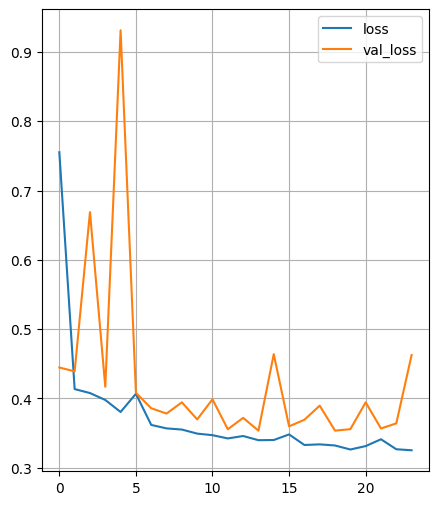

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
pd.DataFrame(keras_reg.history_.history).plot(figsize=(5,6))
plt.grid(True)
plt.show()

In [ ]:
def build_model(hp):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(8,)))

    n_hidden = hp.Int("n_hidden", min_value=1, max_value=4)

    for i in range(n_hidden):

      model.add(keras.layers.Dense(units=hp.Int(f"units_{i}", min_value=32,max_value=256, step=32), activation=hp.Choice(f"activation_{i}",["relu", "elu", "gelu"]), kernel_regularizer=keras.regularizers.l2(hp.Float(f"l2_{i}",min_value=1e-5,max_value=1e-2,sampling="log"))))

      model.add(keras.layers.BatchNormalization())

      model.add(keras.layers.Dropout(hp.Float(f"dropout_{i}",min_value=0.0,max_value=0.5, step=0.1)))

    # Output layer
    model.add(keras.layers.Dense(1))

    # Learning rate
    learning_rate = hp.Float(
        "learning_rate",
        min_value=1e-4,
        max_value=1e-2,
        sampling="log"
    )

    # Optimizer
    optimizer_name = hp.Choice(
        "optimizer",
        ["adam", "nadam", "rmsprop"]
    )

    if optimizer_name == "adam":
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == "nadam":
        optimizer = keras.optimizers.Nadam(learning_rate=learning_rate)
    else:
        optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss=keras.losses.Huber(),
        metrics=["mae"]
    )

    return model

In [ ]:
!pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 7.3 MB/s eta 0:00:00


In [ ]:
import keras_tuner as kt
from tensorflow import keras

tuner = kt.RandomSearch(
    hypermodel=build_model,
    objective="val_loss",
    max_trials=10,
    executions_per_trial=1,
    overwrite=True,
    directory="my_logs",
    project_name="california_housing"
)

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

tensorboard_cb = keras.callbacks.TensorBoard(run_log_cb)

tuner.search(
    X_train_A,
    y_train,
    epochs=100,
    validation_data=(X_valid_A, y_valid),
    callbacks=[early_stop, tensorboard_cb],
    verbose=1
)

Trial 10 Complete [00h 01m 28s]
val_loss: 0.19529348611831665

Best val_loss So Far: 0.1578122079372406
Total elapsed time: 00h 14m 17s


In [ ]:
best_hp = tuner.get_best_hyperparameters(1)[0]

print("Hidden layers :", best_hp.get("n_hidden"))
print("Neurons       :", best_hp.get("n_neurons"))
print("Learning rate :", best_hp.get("learning_rate"))

Hidden layers : 3
Neurons       : 30
Learning rate : 0.0028498164571796065


In [ ]:
best_model = tuner.get_best_models(1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
loss, mae = best_model.evaluate(X_test_A, y_test)

print("Test Loss:", loss)
print("Test MAE :", mae)

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3138 - mae: 0.3569
Test Loss: 0.31375938653945923
Test MAE : 0.3568911850452423


In [ ]:
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,161 (8.44 KB)

 Trainable params: 2,161 (8.44 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = best_model.fit(
    X_train_A,
    y_train,
    epochs=100,
    validation_data=(X_valid_A, y_valid),
    callbacks=[early_stop, tensorboard_cb],
    verbose=1
)

Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.3080 - mae: 0.3633 - val_loss: 0.3247 - val_mae: 0.3729
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3090 - mae: 0.3630 - val_loss: 0.3387 - val_mae: 0.3851
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.3032 - mae: 0.3594 - val_loss: 0.3482 - val_mae: 0.3842
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3050 - mae: 0.3602 - val_loss: 0.3281 - val_mae: 0.3712
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3059 - mae: 0.3604 - val_loss: 0.3232 - val_mae: 0.3815
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3111 - mae: 0.3638 - val_loss: 0.3261 - val_mae: 0.3782
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3035 - mae: 0.3600 - val_loss: 0.3340 - val_mae: 0.3693
Epoch 8/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3036 - mae: 0.3595 - val_loss: 0.3225 - val_mae: 0.3734
Epoch 9/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/

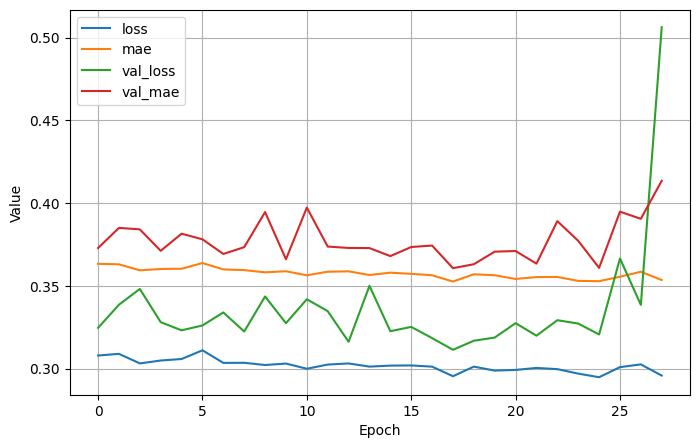

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.show()



```
# Optune is better than all.

Hyperopt:
A popular library for optimizing over all sorts of complex search spaces (including real values, such as the learning rate, and discrete values, such as the number
of layers). Hyperas, kopt, or Talos Useful libraries for optimizing hyperparameters for Keras models (the first two are based on Hyperopt).

Keras Tuner:
An easy-to-use hyperparameter optimization library by Google for Keras models, with a hosted service for visualization and analysis.
Scikit-Optimize (skopt) A general-purpose optimization library. The BayesSearchCV class performs Bayesian optimization using an interface similar to GridSearchCV.

Spearmint:
A Bayesian optimization library Hyperband A fast hyperparameter tuning library based on the recent Hyperband paper22 by Lisha Li et al.

Sklearn-Deap:
A hyperparameter optimization library based on evolutionary algorithms, with a GridSearchCV-like interface.

```



6. you have an MLP composed of one input layer with 10 passthrough
neurons, followed by one hidden layer with 50 artificial neurons, and finally one
output layer with 3 artificial neurons. All artificial"= neurons use the ReLU activa‐
tion function.
• What is the shape of the input matrix X?
• What are the shapes of the hidden layer’s weight vector Wh and its bias vector
bh?
• What are the shapes of the output layer’s weight vector Wo and its bias vector
bo?
• What is the shape of the network’s output matrix Y?
• Write the equation that computes the network’s output matrix Y as a function
of X, Wh, bh, Wo, and bo.

```
X	    (m, 10)	          m training examples, 10 features
Wh      (10, 50)	      10 inputs → 50 hidden neurons
bh      (50) or (1, 50)	  One bias per hidden neuron
Wo      (50, 3)	          50 hidden neurons → 3 output neurons
bo      (3) or (1, 3)	  One bias per output neuron
Y	    (m, 3)	          One output vector (3 values) per training example
```

7. How many neurons do you need in the output layer if you want to classify email into spam or ham? What activation function should you use in the output layer?
If instead you want to tackle MNIST, how many neurons do you need in the out‐
put layer, and which activation function should you use? What about for getting
your network to predict housing prices, as in Chapter 2?

Ans: In output layer architeture need 1 neurons with sigmoid activation function and if its the mnist dataset Problem then Output layer need 10 neurons with softmax.

### **What is reverse-mode automatic differentiation?**

In [ ]:
# Backpropagation algorithm is an implementation of Reverse Mode Auto Differentiation